In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

import warnings
warnings.filterwarnings('ignore') #  Manter visual de saída clean para dar mais foco no coteúdo

#  Configurar visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

Matplotlib is building the font cache; this may take a moment.


In [ ]:
#  Carregar os arquivos CSV
cras = pd.read_csv('CRAS_BRASIL.csv')
creas = pd.read_csv('CREAS_BRASIL.csv')
doacoes2024 = pd.read_csv('doações2024.csv', sep=';', encoding='latin1')
doacoes2025 = pd.read_csv('doadores2025.csv', sep=';', encoding='latin1')
ongs = pd.read_csv('ONGS_SP.csv', sep=';', encoding='latin1')

In [ ]:
#  Filtrar CRAS e CREAS de SP
cras_sp = cras[cras['uf'] == 'SP'].copy()
creas_sp = creas[creas['uf'] == 'SP'].copy()

#  Filtrar doações de SP
doacoes2024_sp = doacoes2024[doacoes2024['uf'] == 'SP'].copy()
doacoes2025_sp = doacoes2025[doacoes2025['uf'] == 'SP'].copy()

#  ONGs já são de SP
ongs_sp = ongs.copy()

Dados filtrados para SP:
CRAS SP: (1245, 15)
CREAS SP: (339, 15)
ONGs SP: (12884, 14)
Doações 2024 SP: (4883, 9)
Doações 2025 SP: (9931, 11)


In [12]:
# F unção para converter string com vírgula decimal para float
def convert_decimal(v):
    if pd.isna(v):
        return np.nan
    return float(str(v).replace(',', '.'))

#  Doações 2024
doacoes2024_sp['latitude'] = pd.to_numeric(doacoes2024_sp['latitude'], errors='coerce') / 1e7
doacoes2024_sp['longitude'] = pd.to_numeric(doacoes2024_sp['longitude'], errors='coerce') / 1e7

#  Doações 2025
doacoes2025_sp['latitude'] = doacoes2025_sp['latitude'].apply(convert_decimal)
doacoes2025_sp['longitude'] = doacoes2025_sp['longitude'].apply(convert_decimal)

#  ONGs SP
ongs_sp['latitude'] = ongs_sp['latitude'].apply(convert_decimal)
ongs_sp['longitude'] = ongs_sp['longitude'].apply(convert_decimal)

#  CRAS SP: extrair de georef_location
def extrair_lat_lon(geo):
    if pd.isna(geo):
        return pd.Series([np.nan, np.nan])
    #  Formato: "-19.300450798730797\,-43.21974277496338"
    partes = geo.replace('\\', '').split(',')
    if len(partes) == 2:
        return pd.Series([float(partes[0]), float(partes[1])])
    else:
        return pd.Series([np.nan, np.nan])

cras_sp[['latitude', 'longitude']] = cras_sp['georef_location'].apply(extrair_lat_lon)

#  CREAS SP
creas_sp[['latitude', 'longitude']] = creas_sp['georef_location'].apply(extrair_lat_lon)

print('Conversão de coordenadas concluída.')

Conversão de coordenadas concluída.


In [ ]:
#  Função para padronizar nomes (maiúsculas, remover acentos)
import unicodedata

def normalize_city(name):
    if pd.isna(name):
        return name
    name = str(name).upper().strip()
    #  Remover acentos
    name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('ASCII')
    return name

#  Aplicar nos DataFrames
cras_sp['cidade_norm'] = cras_sp['cidade'].apply(normalize_city)
creas_sp['cidade_norm'] = creas_sp['cidade'].apply(normalize_city)
ongs_sp['municipio_norm'] = ongs_sp['municipio_nome'].apply(normalize_city)
doacoes2024_sp['municipio_norm'] = doacoes2024_sp['municipio'].apply(normalize_city)

In [ ]:
#  Contagem de ONGs por município
ongs_por_municipio = ongs_sp.groupby('municipio_norm').size().reset_index(name='num_ongs')

#  Contagem de CRAS por município
cras_por_municipio = cras_sp.groupby('cidade_norm').size().reset_index(name='num_cras')

#  Contagem de CREAS por município
creas_por_municipio = creas_sp.groupby('cidade_norm').size().reset_index(name='num_creas')

#  Contagem de doações (apenas 2024, ou combinadas) por município
doacoes_por_municipio = doacoes2024_sp.groupby('municipio_norm').size().reset_index(name='num_doacoes')

#  Unir tudo em um DataFrame
df_municipios = pd.merge(ongs_por_municipio, cras_por_municipio, left_on='municipio_norm', right_on='cidade_norm', how='outer')
df_municipios = pd.merge(df_municipios, creas_por_municipio, left_on='municipio_norm', right_on='cidade_norm', how='outer')
df_municipios = pd.merge(df_municipios, doacoes_por_municipio, on='municipio_norm', how='outer')

#  Preencher NaN com 0
cols_num = ['num_ongs', 'num_cras', 'num_creas', 'num_doacoes']
df_municipios[cols_num] = df_municipios[cols_num].fillna(0).astype(int)

#  Remover colunas redundantes
df_municipios.drop(columns=['cidade_norm_x', 'cidade_norm_y'], errors='ignore', inplace=True)

DataFrame por município criado:


,municipio_norm,num_ongs,num_cras,num_creas,num_doacoes
0,ADAMANTINA,17,1,1,0
1,ADOLFO,1,1,0,0
2,AGUAI,9,1,1,0
3,AGUAS DA PRATA,4,1,0,0
4,AGUAS DE LINDOIA,5,1,0,0
5,AGUDOS,22,1,1,0
6,ALTAIR,2,1,0,0
7,ALTINOPOLIS,6,1,0,0
8,ALUMINIO,7,1,0,0
9,ALVARES FLORENCE,1,1,0,0


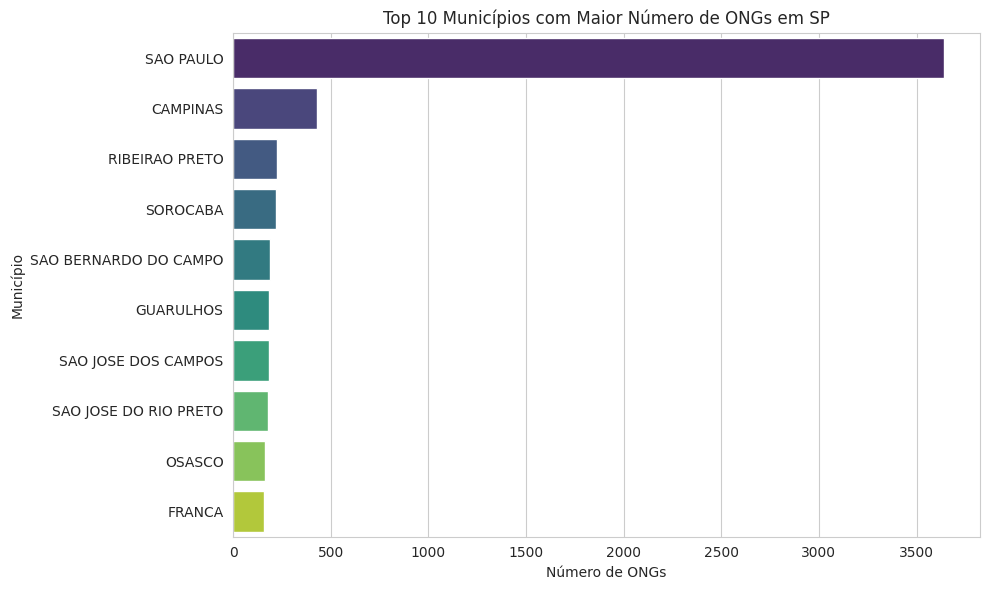

In [18]:
#  Ordenar por número de ONGs (decrescente)
top_ongs = df_municipios.nlargest(10, 'num_ongs')[['municipio_norm', 'num_ongs']]

#  Gráfico de barras horizontais
plt.figure(figsize=(10, 6))
sns.barplot(data=top_ongs, y='municipio_norm', x='num_ongs', palette='viridis')
plt.title('Top 10 Municípios com Maior Número de ONGs em SP')
plt.xlabel('Número de ONGs')
plt.ylabel('Município')
plt.tight_layout()
plt.show()

MUNICÍPIOS SEM NENHUMA ONG
Total de municípios analisados: 658
Municípios sem nenhuma ONG: 119 (18.09%)

Lista completa dos municípios sem ONG (ordenados alfabeticamente):
    municipio_norm  num_ongs
             CANAS         0
    EMBU DAS ARTES         0
            OCAUCU         0
         PAULICEIA         0
SAO PEDRO DO TURVO         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               NaN         0
               N

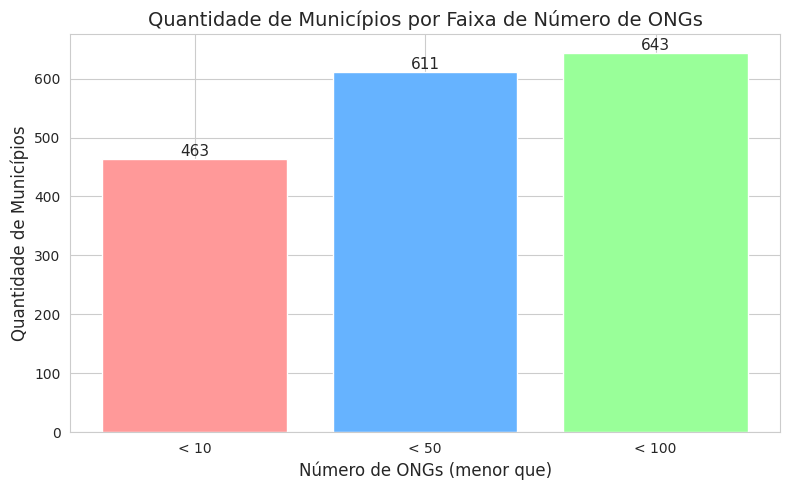

In [20]:
# ==================================================
# Análise complementar: municípios sem ONG e faixas
# ==================================================

# 1. Total de municípios no DataFrame
total_municipios = len(df_municipios)

# 2. Municípios com ZERO ONGs
municipios_sem_ong = df_municipios[df_municipios['num_ongs'] == 0]
quantidade_sem_ong = len(municipios_sem_ong)

print("="*50)
print("MUNICÍPIOS SEM NENHUMA ONG")
print("="*50)
print(f"Total de municípios analisados: {total_municipios}")
print(f"Municípios sem nenhuma ONG: {quantidade_sem_ong} ({quantidade_sem_ong/total_municipios*100:.2f}%)")

if quantidade_sem_ong > 0:
    print("\nLista completa dos municípios sem ONG (ordenados alfabeticamente):")
    # Exibe todos (se não forem muitos). Se houver muitos, pode-se limitar, mas aqui mostramos todos.
    lista_sem_ong = municipios_sem_ong[['municipio_norm', 'num_ongs']].sort_values('municipio_norm')
    print(lista_sem_ong.to_string(index=False))
    
    # Se quiser apenas os primeiros 10, use .head(10) no lugar.
else:
    print("Todos os municípios possuem pelo menos uma ONG.")

print("\n")

# ==================================================
# 3. Quantidade de municípios por faixas de número de ONGs
# ==================================================
menos_10 = df_municipios[df_municipios['num_ongs'] < 10].shape[0]
menos_50 = df_municipios[df_municipios['num_ongs'] < 50].shape[0]
menos_100 = df_municipios[df_municipios['num_ongs'] < 100].shape[0]

print("="*50)
print("QUANTIDADE DE MUNICÍPIOS POR FAIXA DE ONGs")
print("="*50)
print(f"Municípios com menos de 10 ONGs: {menos_10}")
print(f"Municípios com menos de 50 ONGs: {menos_50}")
print(f"Municípios com menos de 100 ONGs: {menos_100}")

# Gráfico de barras para as faixas
faixas = ['< 10', '< 50', '< 100']
quantidades = [menos_10, menos_50, menos_100]

plt.figure(figsize=(8, 5))
bars = plt.bar(faixas, quantidades, color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Quantidade de Municípios por Faixa de Número de ONGs', fontsize=14)
plt.xlabel('Número de ONGs (menor que)', fontsize=12)
plt.ylabel('Quantidade de Municípios', fontsize=12)

# Adicionar rótulos com os valores nas barras
for bar, valor in zip(bars, quantidades):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(valor), 
             ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

Coeficiente de correlação de Pearson: 0.302


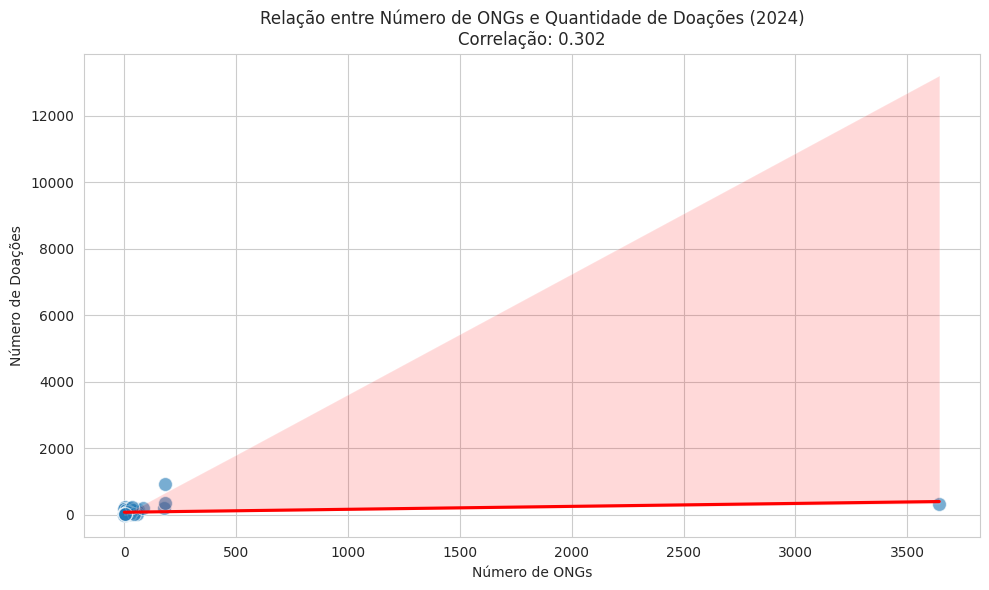

In [ ]:
#  Selecionar apenas municípios com doações registradas (para evitar zeros em doações)
df_corr = df_municipios[df_municipios['num_doacoes'] > 0].copy()

#  Calcular correlação
corr = df_corr['num_ongs'].corr(df_corr['num_doacoes'])
print(f'Coeficiente de correlação de Pearson: {corr:.3f}')

#  Scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_corr, x='num_ongs', y='num_doacoes', alpha=0.6, s=100)
sns.regplot(data=df_corr, x='num_ongs', y='num_doacoes', scatter=False, color='red')
plt.title(f'Relação entre Número de ONGs e Quantidade de Doações (2024)\nCorrelação: {corr:.3f}')
plt.xlabel('Número de ONGs')
plt.ylabel('Número de Doações')
plt.tight_layout()
plt.show()

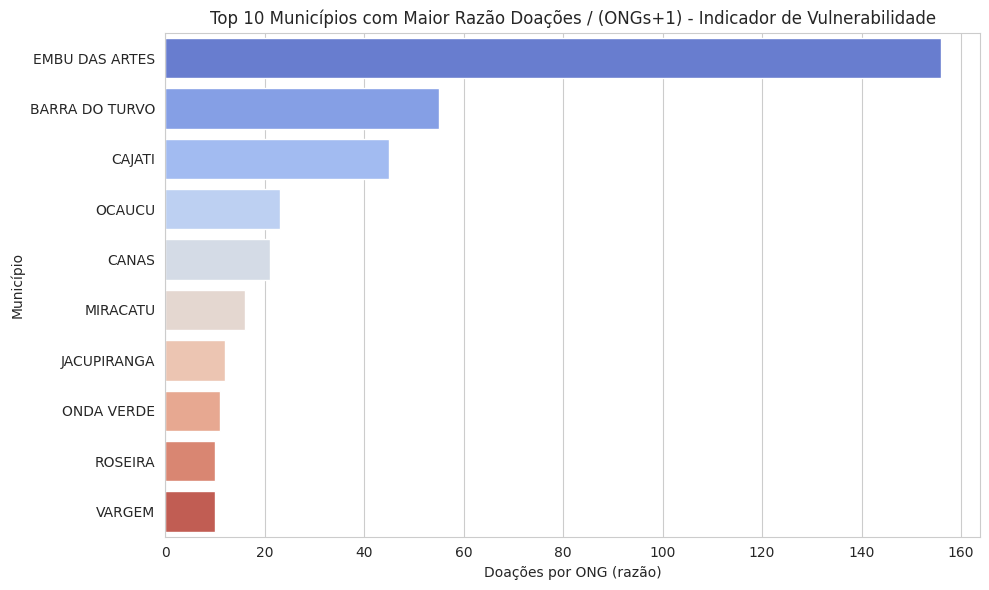

,municipio_norm,num_ongs,num_doacoes,doacoes_por_ong
141,EMBU DAS ARTES,0,156,156.000000
49,BARRA DO TURVO,2,165,55.000000
85,CAJATI,4,225,45.000000
319,OCAUCU,0,23,23.000000
94,CANAS,0,21,21.000000
288,MIRACATU,8,145,16.111111
239,JACUPIRANGA,2,36,12.000000
321,ONDA VERDE,1,22,11.000000
420,ROSEIRA,2,30,10.000000
534,VARGEM,2,30,10.000000


In [ ]:
df_municipios['doacoes_por_ong'] = df_municipios['num_doacoes'] / (df_municipios['num_ongs'] + 1)

#  Top 10 municípios com maior razão (mais vulneráveis)
top_vulneraveis = df_municipios.nlargest(10, 'doacoes_por_ong')[['municipio_norm', 'num_ongs', 'num_doacoes', 'doacoes_por_ong']]

plt.figure(figsize=(10, 6))
sns.barplot(data=top_vulneraveis, y='municipio_norm', x='doacoes_por_ong', palette='coolwarm')
plt.title('Top 10 Municípios com Maior Razão Doações / (ONGs+1) - Indicador de Vulnerabilidade')
plt.xlabel('Doações por ONG (razão)')
plt.ylabel('Município')
plt.tight_layout()
plt.show()

top_vulneraveis